# Signal Generation

A signal is a quantity that varies with an independent variable, such as time. In computational physics, signals can be generated numerically to represent physical measurements, oscillations, pulses, or other time-dependent phenomena.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

In [2]:
plt.rcParams.update({ "font.family": "Times New Roman", "mathtext.fontset": "cm", "font.size": 14 })

In [3]:
def plot(t, x):
    plt.figure(figsize=(5, 5))
    plt.plot(t, x, "r")
    plt.xlabel(r"$t$")
    plt.ylabel(r"$x$")
    plt.tight_layout()
    plt.show()

A continuous-time signal $x(t)$ can be represented computationally by sampling it at discrete time points. For a sampling frequency $f_s$, the sampling interval is

$$
\Delta t = \frac{1}{f_s},
$$

and the sampled time points are

$$
t_k = k\Delta t.
$$

In this notebook, a sampling frequency of

$$
f_s = 1000\ \text{Hz}
$$

is used over a duration of

$$
T = 2\ \text{s}.
$$

In [4]:
fs, T = 1000, 2
t = np.linspace(0, T, int(fs * T), endpoint=False)

## Sinusoidal Signals

A sinusoidal signal is one of the simplest periodic signals:

$$
x(t) = A\sin(2\pi ft + \phi),
$$

where $A$ is the amplitude, $f$ is the frequency, and $\phi$ is the phase. For example,

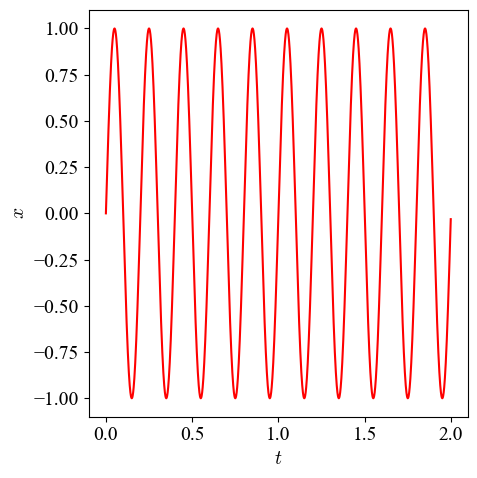

In [5]:
plot(t, np.sin(10 * np.pi * t))

corresponds to

$$
x(t) = \sin(10\pi t) = \sin(2\pi\cdot5t),
$$

so the signal has frequency $f=5$ Hz.

Multiple sinusoidal components can also be combined to produce a more complex periodic signal:

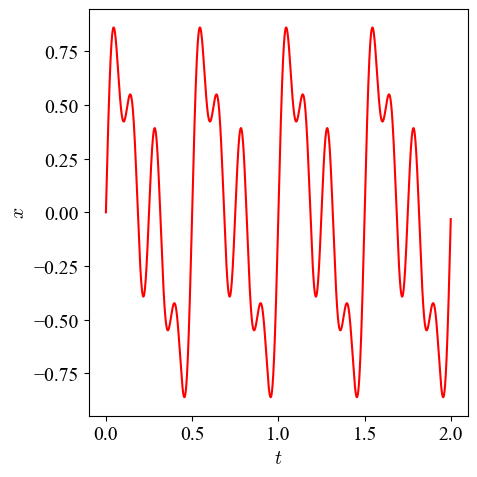

In [6]:
plot(t, 0.5 * np.sin(4 * np.pi * t) + 0.4 * np.sin(8 * np.pi * t) + 0.3 * np.sin(16 * np.pi * t))

This signal is

$$
x(t) = 0.5\sin(4\pi t) + 0.4\sin(8\pi t) + 0.3\sin(16\pi t),
$$

containing frequency components at $2$, $4$, and $8$ Hz.

## Periodic Waveforms

Periodic signals do not have to be sinusoidal. Square and sawtooth waves can also be generated using `scipy.signal`.

A square wave alternates between two amplitude levels:

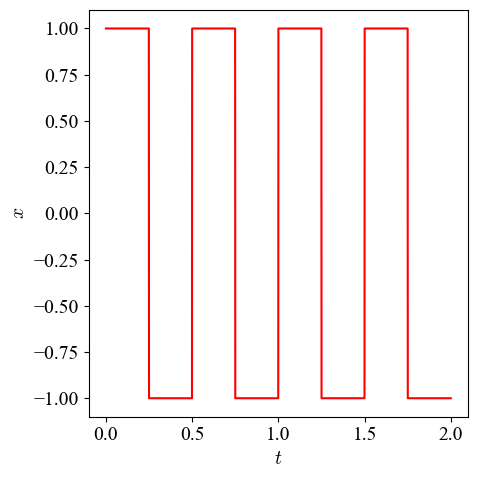

In [7]:
plot(t, signal.square(4 * np.pi * t, duty=0.5))

The `duty` parameter determines the fraction of each period for which the signal is high. With `duty=0.5`, the waveform has a 50% duty cycle.

A sawtooth wave can be generated using

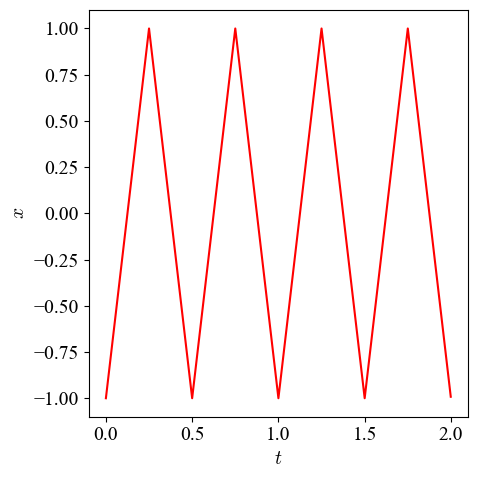

In [8]:
plot(t, signal.sawtooth(4 * np.pi * t, width=0.5))

The `width` parameter controls the position of the peak within each period. A value of $0.5$ produces a symmetric triangular waveform.

## Frequency-Modulated Signals

A chirp is a signal whose instantaneous frequency changes with time. It can be generated using

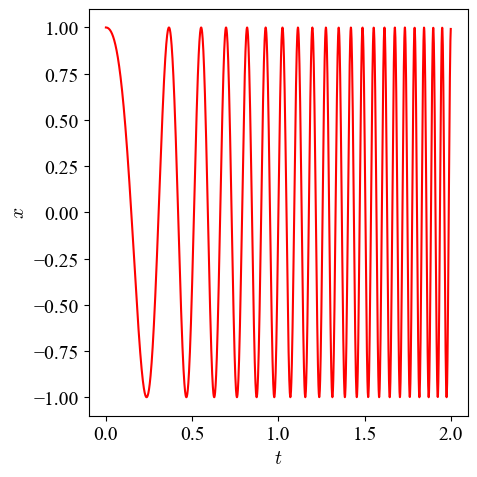

In [9]:
plot(t, signal.chirp(t, f0=1, t1=T, f1=20, method="linear"))

For a linear chirp, the frequency changes approximately linearly from $f_0$ to $f_1$ over the specified interval. In this example,

$$
f_0=1\ \text{Hz},\quad
f_1=20\ \text{Hz}.
$$

Unlike a stationary sinusoidal signal, the oscillation therefore becomes progressively faster with time.

## Pulses

Localized signals can be used to represent short-duration events. A Gaussian pulse is one example:

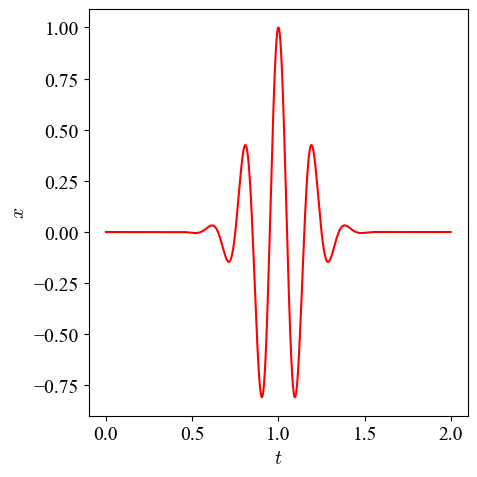

In [10]:
plot(t, signal.gausspulse(t - 1, fc=5))

The signal is centered around $t=1$ s, with `fc=5` controlling its carrier frequency.

An idealized impulse can also be generated:

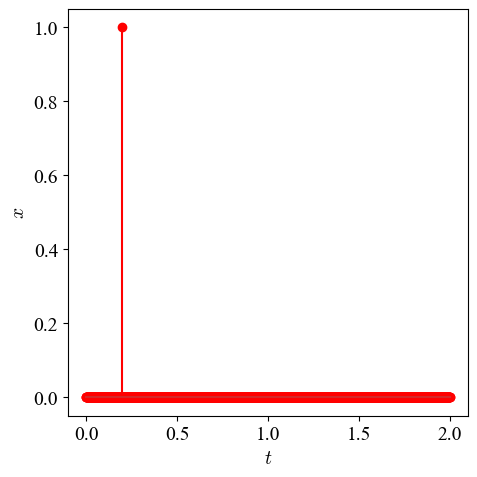

In [11]:
plt.figure(figsize=(5, 5))
plt.stem(t, signal.unit_impulse(len(t), idx=200), "r")
plt.xlabel(r"$t$")
plt.ylabel(r"$x$")
plt.tight_layout()
plt.show()

The discrete impulse is zero everywhere except at the specified sample index. It provides a useful computational representation of the Dirac delta,

$$
\delta(t),
$$

which plays an important role in signal processing and Green's function methods.

## Random Noise

Random signals can be generated by sampling from a probability distribution. Gaussian noise with mean $\mu$ and standard deviation $\sigma$ is generated using

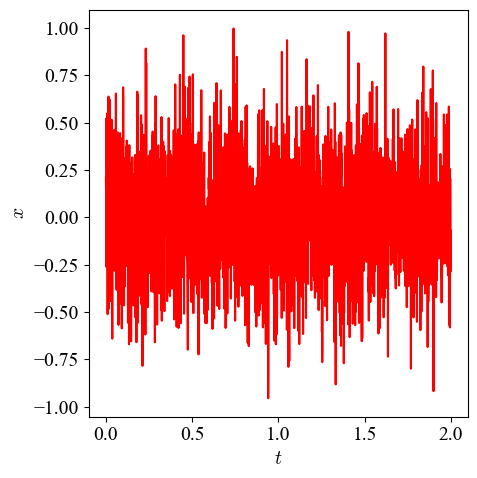

In [12]:
plot(t, np.random.normal(loc=0, scale=0.3, size=len(t)))

The resulting samples follow

$$
x\sim\mathcal{N}(\mu,\sigma^2),
$$

with

$$
\mu=0,\quad
\sigma=0.3.
$$

Random noise is useful for modeling measurement uncertainty and stochastic fluctuations.

## Noisy Signals

A realistic measurement can often be viewed as a combination of an underlying signal and noise:

$$
x_{\mathrm{noisy}}(t) = x_{\mathrm{clean}}(t) + \eta(t),
$$

where $\eta(t)$ represents random noise. For example,

In [13]:
clean = np.sin(2 * np.pi * t) + 0.5 * np.sin(8 * np.pi * t)
noise = np.random.normal(0, 0.1, len(t))

gives the clean signal

$$
x_{\mathrm{clean}}(t) = \sin(2\pi t) + 0.5\sin(8\pi t),
$$

and Gaussian noise with standard deviation $0.1$. The noisy signal is then

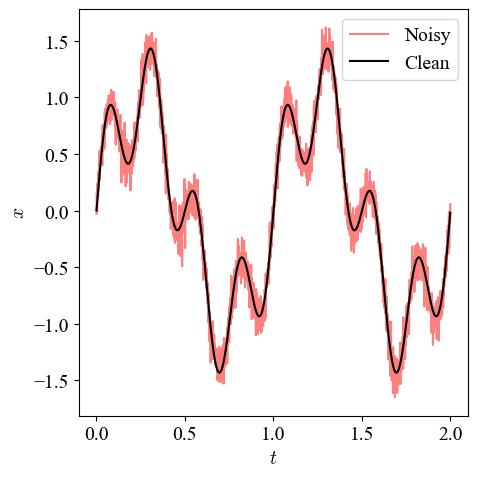

In [14]:
plt.figure(figsize=(5, 5))
plt.plot(t, clean + noise, "r", alpha=0.5, label="Noisy")
plt.plot(t, clean, "k", label="Clean")
plt.xlabel(r"$t$")
plt.ylabel(r"$x$")
plt.legend()
plt.tight_layout()
plt.show()

The resulting plot compares the original signal with its noisy measurement.

## Composite Signals

Physical signals can contain several features simultaneously, such as oscillations with different frequencies, amplitude modulation, phase modulation, transient decay, and random noise. The following example combines several such components:

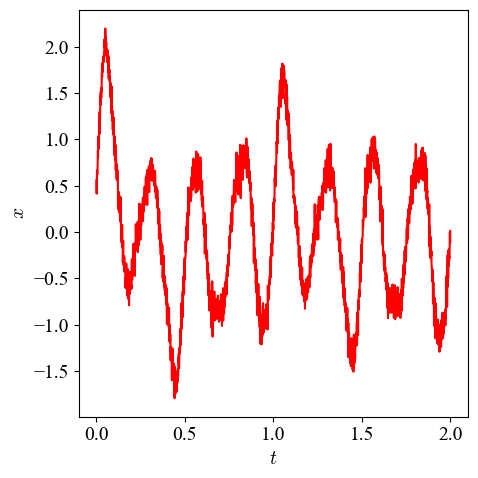

In [15]:
x = (
    np.sin(8 * np.pi * t)
    + 0.2 * (1 + np.sin(10 * np.pi * t)) * np.sin(12 * np.pi * t)
    + 0.2 * np.sin(4 * np.pi * t + np.sin(6 * np.pi * t))
    + 0.5 * np.exp(-t) * np.cos(2 * np.pi * t)
    + np.random.normal(loc=0, scale=0.1, size=len(t))
)
plot(t, x)

The resulting signal contains a combination of

* a sinusoidal component,
* amplitude modulation,
* phase modulation,
* a decaying oscillation,
* and Gaussian noise.

This type of composite signal is useful for illustrating why signal processing is necessary: different physical features can be superimposed in a single observed signal and may need to be separated or characterized through subsequent analysis.